# Consumo de Água no Brasil (2015–2024)

## Projeto G1 — Análise e Visualização de Dados com Python

**Tema 7:** Consumo de Água no Brasil
**Aluno:** Marcus Vinicius Rodrigues da Silva

# 1. Introdução

A proposta é investigar padrões de consumo de água no Brasil entre 2015 e 2024, cruzando o volume consumido com variáveis ambientais (chuva, temperatura, nível dos reservatórios) e operacionais (desperdício, setor de consumo, nível de alerta).

O resultado esperado não é só um conjunto de gráficos, mas respostas às perguntas orientadoras do tema, com uma leitura crítica do que a base permite ou não permite concluir.

# 2. Contextualização ambiental

A água é essencial para o abastecimento urbano, a agricultura, a indústria, a geração de energia e a saúde pública. Três fatores tornam o monitoramento do consumo cada vez mais importante:

- **Crescimento populacional**, que aumenta a demanda sobre os mesmos mananciais.
- **Mudanças climáticas**, que tornam os períodos de estiagem mais frequentes e intensos e reduzem a recarga dos reservatórios.
- **Desperdício**, que inclui vazamentos nas redes de distribuição, ligações irregulares e uso ineficiente. Cada litro perdido é um litro captado, tratado e bombeado sem chegar a quem precisa.

Em crises hídricas, o nível dos reservatórios é o indicador mais acompanhado, porque mostra quanto de margem existe antes de racionamento. Por isso, este projeto trata reservatórios, chuva e desperdício como indicadores centrais, ao lado do volume consumido.

# 3. Perguntas orientadoras

1. Quais estados apresentam maior consumo de água?
2. Existe sazonalidade no consumo?
3. Quais setores consomem mais água?
4. Há regiões mais vulneráveis à escassez?
5. Existe relação entre estiagem e consumo?
6. Houve aumento do consumo ao longo do tempo?
7. Quais estados apresentam maiores índices de desperdício?

# 4. Explicação da base de dados

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período de referência da medição |
| `regiao`, `uf` | Região e estado |
| `setor_consumo` | Agrícola, Comercial, Industrial, Público ou Residencial |
| `consumo_milhoes_litros` | Volume consumido no mês, em milhões de litros |
| `desperdicio_percentual` | Percentual estimado de perdas |
| `reservatorios_percentual` | Nível dos reservatórios (% da capacidade) |
| `chuva_mm` | Volume de chuva no mês (mm) |
| `temperatura_media` | Temperatura média do mês (°C) |
| `populacao` | População estimada |
| `consumo_per_capita` | Consumo médio por pessoa (litros/dia) |
| `nivel_alerta` | Baixo, Médio, Alto ou Crítico |

# 5. Importação das bibliotecas

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sqlalchemy import create_engine, ForeignKey, String, Integer, Float, text
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.options.display.float_format = "{:,.2f}".format

AZUL = "#1F6F8B"
AZUL_CLARO = "#8EC3D1"
AZUL_ESCURO = "#12394A"
OCRE = "#B7791F"
PALETA_SETORES = ["#12394A", "#1F6F8B", "#4A9BB5", "#8EC3D1", "#5E8C6A"]

def br(valor, casas=2):
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# 6. Leitura dos dados

In [4]:
candidatos = [
    Path("../dados/simulacao_consumo_agua_brasil.csv"),
    Path("dados/simulacao_consumo_agua_brasil.csv"),
    Path("simulacao_consumo_agua_brasil.csv"),
]
CAMINHO_CSV = next(p for p in candidatos if p.exists())
RAIZ = CAMINHO_CSV.resolve().parent.parent if CAMINHO_CSV.parent.name == "dados" else Path(".").resolve()
PASTA_IMAGENS = RAIZ / "imagens"
PASTA_DATABASE = RAIZ / "database"
PASTA_IMAGENS.mkdir(exist_ok=True)
PASTA_DATABASE.mkdir(exist_ok=True)

def salvar(fig, nome):
    fig.savefig(PASTA_IMAGENS / f"{nome}.png", dpi=150, bbox_inches="tight")

df_bruto = pd.read_csv(CAMINHO_CSV)
df_bruto.head()

,ano,mes,data,regiao,uf,setor_consumo,consumo_milhoes_litros,desperdicio_percentual,reservatorios_percentual,chuva_mm,temperatura_media,populacao,consumo_per_capita,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Público,6.64,18.56,52.75,316.70,26.10,2440046,244.63,Médio
1,2015,1,2015-01-01,Norte,PA,Agrícola,19.81,9.63,21.75,190.00,24.40,2340035,143.77,Crítico
2,2015,1,2015-01-01,Norte,PA,Agrícola,20.54,28.69,25.44,163.50,27.40,5917187,318.44,Baixo
3,2015,1,2015-01-01,Norte,RO,Residencial,30.18,15.75,54.90,30.90,22.70,1950109,313.67,Baixo
4,2015,1,2015-01-01,Norte,TO,Comercial,34.61,17.66,50.44,136.60,25.20,3246728,380.89,Alto


# 7. Check-up inicial da base

In [5]:
print("Dimensões da base:", df_bruto.shape)
print("\nTipos de dados:")
print(df_bruto.dtypes)
print("\nValores ausentes por coluna:")
print(df_bruto.isnull().sum())
print("\nLinhas duplicadas:", df_bruto.duplicated().sum())

Dimensões da base: (4440, 14)

Tipos de dados:
ano                           int64
mes                           int64
data                            str
regiao                          str
uf                              str
setor_consumo                   str
consumo_milhoes_litros      float64
desperdicio_percentual      float64
reservatorios_percentual    float64
chuva_mm                    float64
temperatura_media           float64
populacao                     int64
consumo_per_capita          float64
nivel_alerta                    str
dtype: object

Valores ausentes por coluna:
ano                         0
mes                         0
data                        0
regiao                      0
uf                          0
setor_consumo               0
consumo_milhoes_litros      0
desperdicio_percentual      0
reservatorios_percentual    0
chuva_mm                    0
temperatura_media           0
populacao                   0
consumo_per_capita          0
nivel_alerta   

In [6]:
df_bruto.describe().T

,count,mean,std,min,25%,50%,75%,max
ano,"4,440.00","2,019.50",2.87,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
mes,"4,440.00",6.50,3.45,1.00,3.75,6.50,9.25,12.00
consumo_milhoes_litros,"4,440.00",20.85,10.93,2.00,11.24,20.76,30.40,39.99
desperdicio_percentual,"4,440.00",30.19,14.31,5.00,18.02,30.23,42.50,55.00
reservatorios_percentual,"4,440.00",52.17,27.43,5.01,28.25,51.79,76.18,99.99
chuva_mm,"4,440.00",106.40,60.92,2.00,62.20,94.05,137.62,472.20
temperatura_media,"4,440.00",25.96,2.99,16.00,23.90,26.00,28.00,35.60
populacao,"4,440.00","3,081,847.42","1,718,687.57","102,522.00","1,585,290.00","3,098,709.00","4,569,367.50","5,998,136.00"
consumo_per_capita,"4,440.00",266.52,107.53,80.01,173.13,265.81,358.20,449.95


In [7]:
for coluna in ["regiao", "uf", "setor_consumo", "nivel_alerta"]:
    print(f"{coluna}: {sorted(df_bruto[coluna].unique())}")

print("\nPeríodo:", df_bruto["data"].min(), "a", df_bruto["data"].max())
print("Meses distintos:", df_bruto["data"].nunique())

regiao: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
uf: ['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PR', 'RJ', 'RO', 'RS', 'SC', 'SP', 'TO']
setor_consumo: ['Agrícola', 'Comercial', 'Industrial', 'Público', 'Residencial']
nivel_alerta: ['Alto', 'Baixo', 'Crítico', 'Médio']

Período: 2015-01-01 a 2024-12-01
Meses distintos: 120


**Leitura do check-up:** a base tem 4.440 linhas e 14 colunas, sem valores ausentes e sem duplicatas. Cobre 120 meses (jan/2015 a dez/2024), 5 regiões, 20 estados e 5 setores. A coluna `data` veio como texto e precisa ser convertida.

Um ponto importante aparece ao contar os registros por estado:

In [8]:
registros_uf = df_bruto["uf"].value_counts().rename("registros").to_frame()
registros_uf["registros_por_mes"] = registros_uf["registros"] / df_bruto["data"].nunique()
registros_uf.T

uf,RJ,SP,MG,ES,PA,BA,PE,CE,GO,PR,SC,RS,AM,RO,TO,MA,PB,DF,MT,MS
registros,480.00,360.00,360.00,360.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
registros_por_mes,4.00,3.00,3.00,3.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Os estados **não têm a mesma quantidade de medições**: o RJ tem 4 registros por mês, SP, MG e ES têm 3, e oito estados têm apenas 1. Isso significa que qualquer comparação baseada em **soma** favorece os estados com mais registros. Por isso, ao longo da análise, o ranking por consumo total é sempre acompanhado do **consumo médio por medição**, que é a comparação justa.

# 8. Limpeza e preparação

In [ ]:
df = df_bruto.copy()

for coluna in ["regiao", "uf", "setor_consumo", "nivel_alerta"]:
    df[coluna] = df[coluna].astype(str).str.strip()
df["uf"] = df["uf"].str.upper()

df["data"] = pd.to_datetime(df["data"], errors="coerce")

inconsistentes = ((df["data"].dt.year != df["ano"]) | (df["data"].dt.month != df["mes"])).sum()
print("Linhas com ano/mês divergentes da data:", inconsistentes)

regras = {
    "consumo_milhoes_litros": df["consumo_milhoes_litros"] > 0,
    "desperdicio_percentual": df["desperdicio_percentual"].between(0, 100),
    "reservatorios_percentual": df["reservatorios_percentual"].between(0, 100),
    "chuva_mm": df["chuva_mm"] >= 0,
    "populacao": df["populacao"] > 0,
    "consumo_per_capita": df["consumo_per_capita"] > 0,
}
for coluna, valido in regras.items():
    print(f"{coluna}: {(~valido).sum()} valores fora da faixa")

df = df.drop_duplicates().dropna(subset=["data"])

ordem_alerta = ["Baixo", "Médio", "Alto", "Crítico"]
df["nivel_alerta"] = pd.Categorical(df["nivel_alerta"], categories=ordem_alerta, ordered=True)

print("\nBase após a limpeza:", df.shape)

Linhas com ano/mês divergentes da data: 0
consumo_milhoes_litros: 0 valores fora da faixa
desperdicio_percentual: 0 valores fora da faixa
reservatorios_percentual: 0 valores fora da faixa
chuva_mm: 0 valores fora da faixa
populacao: 0 valores fora da faixa
consumo_per_capita: 0 valores fora da faixa

Base após a limpeza: (4440, 14)


### Verificação de outliers (método IQR)

Valores fora de 1,5 × IQR são marcados apenas para inspeção. Como não há valores impossíveis (todas as faixas foram validadas acima), nenhum registro é removido.

In [10]:
colunas_numericas = ["consumo_milhoes_litros", "desperdicio_percentual", "reservatorios_percentual",
                     "chuva_mm", "temperatura_media", "consumo_per_capita"]
resumo_outliers = {}
for coluna in colunas_numericas:
    q1, q3 = df[coluna].quantile([0.25, 0.75])
    iqr = q3 - q1
    resumo_outliers[coluna] = int(((df[coluna] < q1 - 1.5 * iqr) | (df[coluna] > q3 + 1.5 * iqr)).sum())
pd.Series(resumo_outliers, name="outliers_iqr").to_frame()

,outliers_iqr
consumo_milhoes_litros,0
desperdicio_percentual,0
reservatorios_percentual,0
chuva_mm,117
temperatura_media,28
consumo_per_capita,0


In [15]:
verificacao = df[["consumo_milhoes_litros", "populacao", "consumo_per_capita"]].head().copy()
verificacao["per_capita_calculado_l_dia"] = (
    verificacao["consumo_milhoes_litros"] * 1_000_000 / verificacao["populacao"] / 30
)
verificacao

,consumo_milhoes_litros,populacao,consumo_per_capita,per_capita_calculado_l_dia
0,6.64,2440046,244.63,0.09
1,19.81,2340035,143.77,0.28
2,20.54,5917187,318.44,0.12
3,30.18,1950109,313.67,0.52
4,34.61,3246728,380.89,0.36


# 9. Engenharia de atributos

| Novo atributo | Como é calculado | Para que serve |
|---|---|---|
| `ano_mes` | Período no formato AAAA-MM | Séries mensais |
| `trimestre` | Trimestre da data | Agregações trimestrais |
| `estacao` | Estação do ano no hemisfério sul | Sazonalidade |
| `volume_perdido` | consumo × desperdício ÷ 100 | Quanto do consumo foi perdido |
| `consumo_aproveitado` | consumo − volume perdido | Água que efetivamente chegou ao uso |
| `faixa_reservatorio` | Faixas de 0–30, 30–50, 50–70 e 70–100% | Situação hídrica categorizada |
| `estiagem` | Chuva abaixo do 1º quartil da base | Comparar meses secos e normais |
| `alerta_grave` | Nível de alerta Alto ou Crítico | Proporção de situações graves |

In [12]:
ESTACOES = {12: "Verão", 1: "Verão", 2: "Verão",
            3: "Outono", 4: "Outono", 5: "Outono",
            6: "Inverno", 7: "Inverno", 8: "Inverno",
            9: "Primavera", 10: "Primavera", 11: "Primavera"}

df["ano_mes"] = df["data"].dt.to_period("M").astype(str)
df["trimestre"] = df["data"].dt.quarter
df["estacao"] = df["mes"].map(ESTACOES)

df["volume_perdido"] = df["consumo_milhoes_litros"] * df["desperdicio_percentual"] / 100
df["consumo_aproveitado"] = df["consumo_milhoes_litros"] - df["volume_perdido"]

df["faixa_reservatorio"] = pd.cut(
    df["reservatorios_percentual"], bins=[0, 30, 50, 70, 100],
    labels=["Crítico (≤30%)", "Baixo (30–50%)", "Moderado (50–70%)", "Confortável (>70%)"],
    include_lowest=True,
)

LIMITE_ESTIAGEM = df["chuva_mm"].quantile(0.25)
df["estiagem"] = np.where(df["chuva_mm"] < LIMITE_ESTIAGEM, "Estiagem", "Chuva normal")
df["alerta_grave"] = df["nivel_alerta"].isin(["Alto", "Crítico"])

print(f"Limite de estiagem (1º quartil da chuva): {br(LIMITE_ESTIAGEM, 1)} mm")
df.head()

Limite de estiagem (1º quartil da chuva): 62,2 mm


,ano,mes,data,regiao,uf,setor_consumo,consumo_milhoes_litros,desperdicio_percentual,reservatorios_percentual,chuva_mm,...,consumo_per_capita,nivel_alerta,ano_mes,trimestre,estacao,volume_perdido,consumo_aproveitado,faixa_reservatorio,estiagem,alerta_grave
0,2015,1,2015-01-01,Norte,AM,Público,6.64,18.56,52.75,316.70,...,244.63,Médio,2015-01,1,Verão,1.23,5.41,Moderado (50–70%),Chuva normal,False
1,2015,1,2015-01-01,Norte,PA,Agrícola,19.81,9.63,21.75,190.00,...,143.77,Crítico,2015-01,1,Verão,1.91,17.90,Crítico (≤30%),Chuva normal,True
2,2015,1,2015-01-01,Norte,PA,Agrícola,20.54,28.69,25.44,163.50,...,318.44,Baixo,2015-01,1,Verão,5.89,14.65,Crítico (≤30%),Chuva normal,False
3,2015,1,2015-01-01,Norte,RO,Residencial,30.18,15.75,54.90,30.90,...,313.67,Baixo,2015-01,1,Verão,4.75,25.43,Moderado (50–70%),Estiagem,False
4,2015,1,2015-01-01,Norte,TO,Comercial,34.61,17.66,50.44,136.60,...,380.89,Alto,2015-01,1,Verão,6.11,28.50,Moderado (50–70%),Chuva normal,True


# 10. KPIs

Os KPIs seguem o que o tema pede (seções 9 do enunciado) e acrescentam dois indicadores ambientais: o volume perdido e a proporção de medições em alerta grave.

In [13]:
consumo_total = df["consumo_milhoes_litros"].sum()

consumo_uf = df.groupby("uf")["consumo_milhoes_litros"].agg(["sum", "mean", "count"])
uf_maior_total = consumo_uf["sum"].idxmax()
uf_maior_media = consumo_uf["mean"].idxmax()

consumo_setor = df.groupby("setor_consumo")["consumo_milhoes_litros"].sum()
setor_maior = consumo_setor.idxmax()

per_capita_medio = df["consumo_per_capita"].mean()
desperdicio_medio = df["desperdicio_percentual"].mean()
reservatorio_medio = df["reservatorios_percentual"].mean()
volume_perdido = df["volume_perdido"].sum()
pct_alerta_grave = df["alerta_grave"].mean()

kpis = pd.DataFrame({
    "KPI": ["Consumo total de água", "Estado com maior consumo (total)", "Estado com maior consumo (média por medição)",
            "Setor que mais consome", "Consumo per capita médio", "Média de desperdício",
            "Nível médio dos reservatórios", "Volume perdido", "Medições em alerta Alto ou Crítico"],
    "Valor": [f"{br(consumo_total)} milhões de litros",
              f"{uf_maior_total} ({br(consumo_uf.loc[uf_maior_total, 'sum'])} mi L)",
              f"{uf_maior_media} ({br(consumo_uf.loc[uf_maior_media, 'mean'])} mi L por medição)",
              f"{setor_maior} ({br(consumo_setor.max())} mi L)",
              f"{br(per_capita_medio)} litros/pessoa/dia",
              f"{br(desperdicio_medio)}%",
              f"{br(reservatorio_medio)}%",
              f"{br(volume_perdido)} milhões de litros",
              f"{br(pct_alerta_grave * 100, 1)}%"],
})
kpis

,KPI,Valor
0,Consumo total de água,"92.566,21 milhões de litros"
1,Estado com maior consumo (total),"RJ (10.175,87 mi L)"
2,Estado com maior consumo (média por medição),"BA (22,06 mi L por medição)"
3,Setor que mais consome,"Agrícola (19.256,48 mi L)"
4,Consumo per capita médio,"266,52 litros/pessoa/dia"
5,Média de desperdício,"30,19%"
6,Nível médio dos reservatórios,"52,17%"
7,Volume perdido,"27.870,51 milhões de litros"
8,Medições em alerta Alto ou Crítico,"50,7%"


# 11. Análise exploratória e visualizações

## 11.1 Evolução temporal do consumo

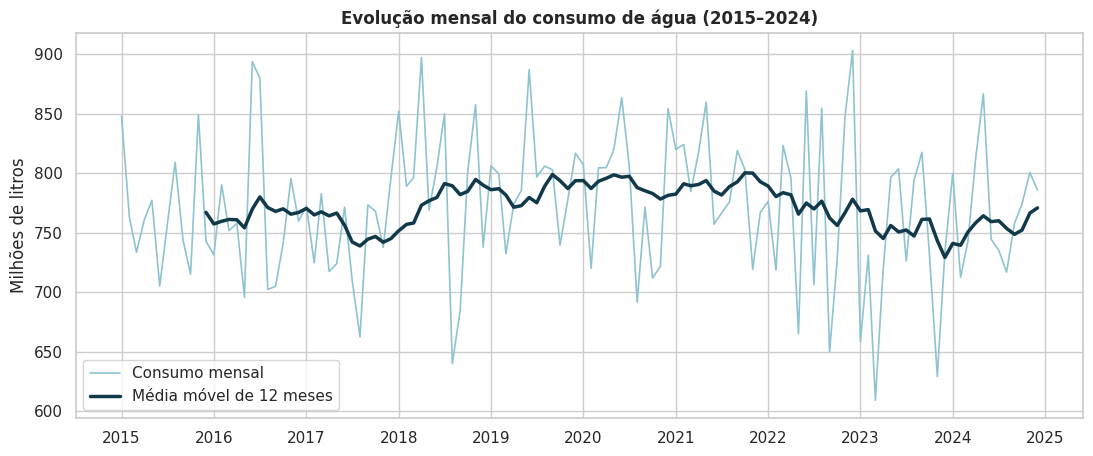

In [12]:
serie_mensal = (
    df.groupby("data")
    .agg(consumo=("consumo_milhoes_litros", "sum"),
         chuva=("chuva_mm", "mean"),
         reservatorios=("reservatorios_percentual", "mean"))
    .sort_index()
)
serie_mensal["media_movel_12m"] = serie_mensal["consumo"].rolling(12).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_mensal.index, serie_mensal["consumo"], color=AZUL_CLARO, linewidth=1.2, label="Consumo mensal")
ax.plot(serie_mensal.index, serie_mensal["media_movel_12m"], color=AZUL_ESCURO, linewidth=2.5,
        label="Média móvel de 12 meses")
ax.set_title("Evolução mensal do consumo de água (2015–2024)")
ax.set_xlabel("")
ax.set_ylabel("Milhões de litros")
ax.legend(loc="lower left")
salvar(fig, "evolucao_temporal")
plt.show()

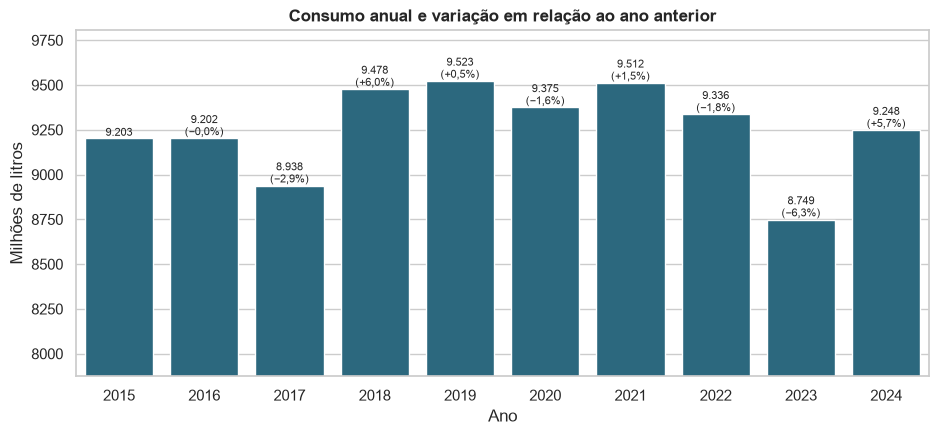

Variação 2015 → 2024: +0.49%
Inclinação da tendência linear: -5,00 milhões de litros por ano


In [14]:
consumo_anual = df.groupby("ano")["consumo_milhoes_litros"].sum().to_frame("consumo")
consumo_anual["variacao_anual_%"] = consumo_anual["consumo"].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=consumo_anual.index, y=consumo_anual["consumo"], color=AZUL, ax=ax)
ax.set_ylim(consumo_anual["consumo"].min() * 0.9, consumo_anual["consumo"].max() * 1.03)
for i, (valor, var) in enumerate(zip(consumo_anual["consumo"], consumo_anual["variacao_anual_%"])):
    rotulo = br(valor, 0) if np.isnan(var) else f"{br(valor, 0)}\n({'+' if var >= 0 else '−'}{br(abs(var), 1)}%)"
    ax.text(i, valor, rotulo, ha="center", va="bottom", fontsize=8)
ax.set_title("Consumo anual e variação em relação ao ano anterior")
ax.set_xlabel("Ano")
ax.set_ylabel("Milhões de litros")
salvar(fig, "consumo_anual")
plt.show()

variacao_periodo = consumo_anual["consumo"].iloc[-1] / consumo_anual["consumo"].iloc[0] - 1
tendencia = np.polyfit(consumo_anual.index, consumo_anual["consumo"], 1)[0]
print(f"Variação 2015 → 2024: {variacao_periodo:+.2%}")
print(f"Inclinação da tendência linear: {br(tendencia)} milhões de litros por ano")

**Interpretação:** o consumo oscila mês a mês, mas a média móvel de 12 meses fica praticamente estável, entre cerca de 730 e 800 milhões de litros por mês. Entre 2015 e 2024 a variação total é de +0,5%, e a tendência linear é levemente negativa (cerca de −5 milhões de litros por ano, menos de 0,1% do volume anual). O ano de menor consumo foi 2023 e o de maior foi 2019. **Não há tendência clara de aumento do consumo** no período.

## 11.2 Sazonalidade

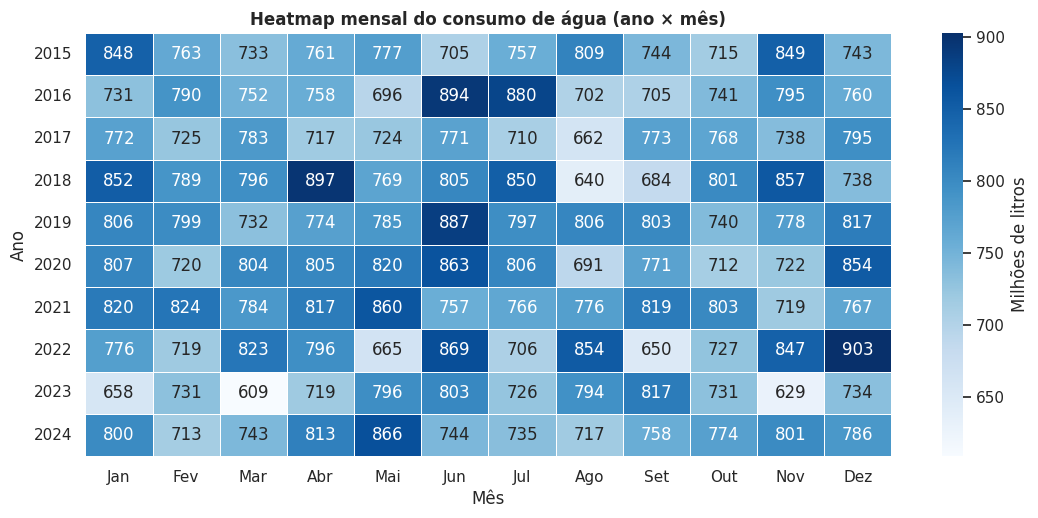

In [14]:
matriz_sazonal = df.pivot_table(index="ano", columns="mes", values="consumo_milhoes_litros", aggfunc="sum")
matriz_sazonal.columns = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(matriz_sazonal, cmap="Blues", annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label": "Milhões de litros"}, ax=ax)
ax.set_title("Heatmap mensal do consumo de água (ano × mês)")
ax.tick_params(axis="y", rotation=0)
ax.set_xlabel("Mês")
ax.set_ylabel("Ano")
salvar(fig, "heatmap_sazonalidade")
plt.show()

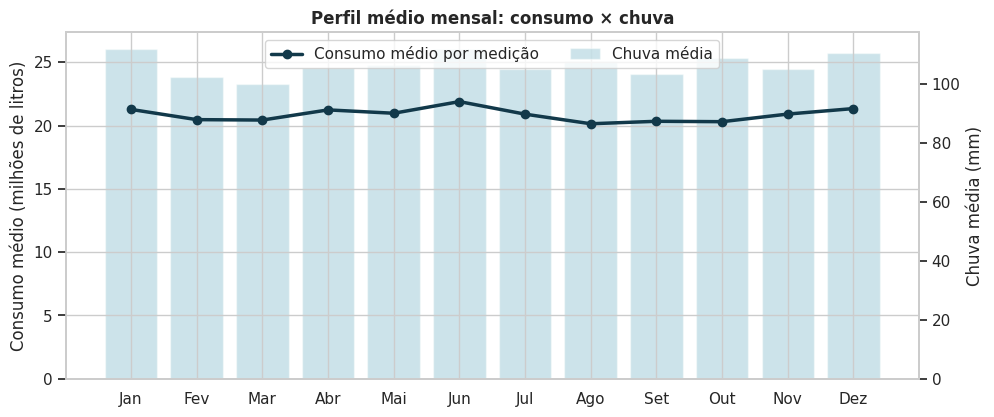

Mês de maior consumo médio: 6
Mês de menor consumo médio: 8
Diferença entre o maior e o menor mês: 8,7%


In [15]:
perfil_mensal = df.groupby("mes").agg(
    consumo_medio=("consumo_milhoes_litros", "mean"),
    chuva_media=("chuva_mm", "mean"),
    temperatura_media=("temperatura_media", "mean"),
)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(perfil_mensal.index, perfil_mensal["consumo_medio"], marker="o", color=AZUL_ESCURO, linewidth=2.5,
         label="Consumo médio por medição")
ax1.set_ylabel("Consumo médio (milhões de litros)")
ax1.set_ylim(0, perfil_mensal["consumo_medio"].max() * 1.25)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(matriz_sazonal.columns)
ax2 = ax1.twinx()
ax2.bar(perfil_mensal.index, perfil_mensal["chuva_media"], color=AZUL_CLARO, alpha=0.45, label="Chuva média")
ax2.set_ylabel("Chuva média (mm)")
ax2.grid(False)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax1.set_title("Perfil médio mensal: consumo × chuva")
linhas = ax1.get_legend_handles_labels()
barras = ax2.get_legend_handles_labels()
ax1.legend(linhas[0] + barras[0], linhas[1] + barras[1], loc="upper center", ncol=2)
salvar(fig, "perfil_mensal")
plt.show()

amplitude = (perfil_mensal["consumo_medio"].max() / perfil_mensal["consumo_medio"].min() - 1) * 100
print(f"Mês de maior consumo médio: {perfil_mensal['consumo_medio'].idxmax()}")
print(f"Mês de menor consumo médio: {perfil_mensal['consumo_medio'].idxmin()}")
print(f"Diferença entre o maior e o menor mês: {br(amplitude, 1)}%")

In [16]:
consumo_estacao = (
    df.groupby("estacao")["consumo_milhoes_litros"].mean()
    .reindex(["Verão", "Outono", "Inverno", "Primavera"])
)
consumo_estacao.to_frame("consumo_medio_por_medicao")

,consumo_medio_por_medicao
estacao,
Verão,21.03
Outono,20.88
Inverno,20.98
Primavera,20.51


**Interpretação:** o heatmap não mostra um padrão que se repita todos os anos. Os meses mais escuros mudam de posição de um ano para outro. No perfil médio, junho é o mês de maior consumo e agosto o de menor, mas a diferença entre eles é de cerca de 9%, e a média por estação fica praticamente igual. A chuva média mensal também não segue o ciclo de estação seca e chuvosa esperado para boa parte do país. **Na base, a sazonalidade do consumo é fraca ou inexistente.**

## 11.3 Comparação entre regiões

In [17]:
resumo_regiao = (
    df.groupby("regiao")
    .agg(consumo_total=("consumo_milhoes_litros", "sum"),
         consumo_medio=("consumo_milhoes_litros", "mean"),
         medicoes=("uf", "size"),
         desperdicio_medio=("desperdicio_percentual", "mean"),
         reservatorios_medio=("reservatorios_percentual", "mean"),
         chuva_media=("chuva_mm", "mean"))
    .sort_values("consumo_total", ascending=False)
)
resumo_regiao

,consumo_total,consumo_medio,medicoes,desperdicio_medio,reservatorios_medio,chuva_media
regiao,,,,,,
Sudeste,"32,497.94",20.83,1560,30.16,52.10,104.33
Nordeste,"20,252.66",21.10,960,30.49,51.98,106.47
Sul,"15,145.77",21.04,720,30.26,51.71,106.92
Centro-Oeste,"12,371.52",20.62,600,30.49,52.91,105.05
Norte,"12,298.32",20.50,600,29.42,52.46,112.37


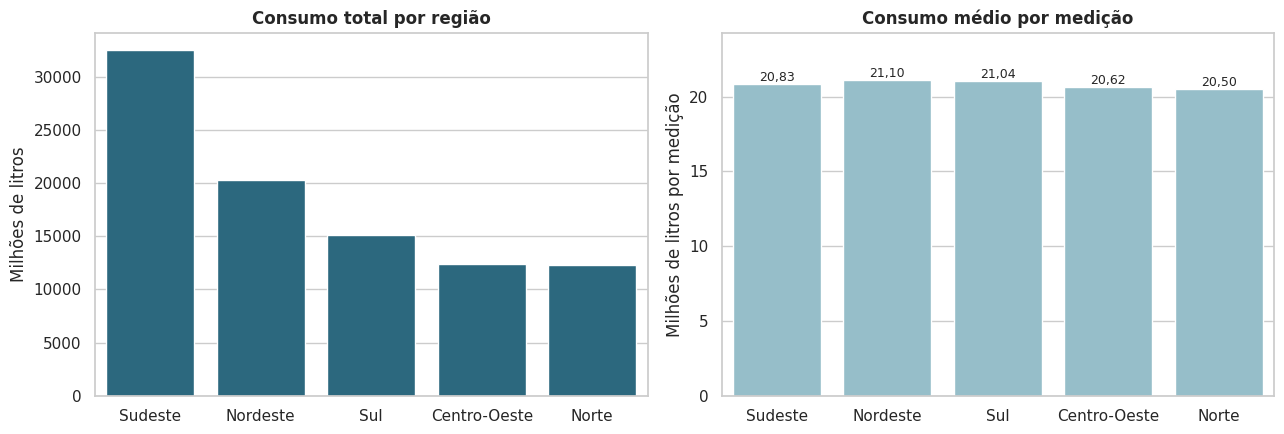

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=resumo_regiao.index, y=resumo_regiao["consumo_total"], color=AZUL, ax=axes[0])
axes[0].set_title("Consumo total por região")
axes[0].set_xlabel("")
axes[0].set_ylabel("Milhões de litros")

sns.barplot(x=resumo_regiao.index, y=resumo_regiao["consumo_medio"], color=AZUL_CLARO, ax=axes[1])
axes[1].set_title("Consumo médio por medição")
axes[1].set_xlabel("")
axes[1].set_ylabel("Milhões de litros por medição")
axes[1].set_ylim(0, resumo_regiao["consumo_medio"].max() * 1.15)
for i, v in enumerate(resumo_regiao["consumo_medio"]):
    axes[1].text(i, v, br(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
salvar(fig, "regioes")
plt.show()

**Interpretação:** o Sudeste concentra o maior consumo total (cerca de 35% da base), seguido do Nordeste. Mas isso reflete o número de medições: o Sudeste tem 1.560 registros contra 600 do Norte. Na média por medição, as regiões ficam todas entre 20,5 e 21,1 milhões de litros, com Nordeste e Sul ligeiramente acima. A diferença real de intensidade de consumo entre regiões é pequena.

## 11.4 Ranking de estados

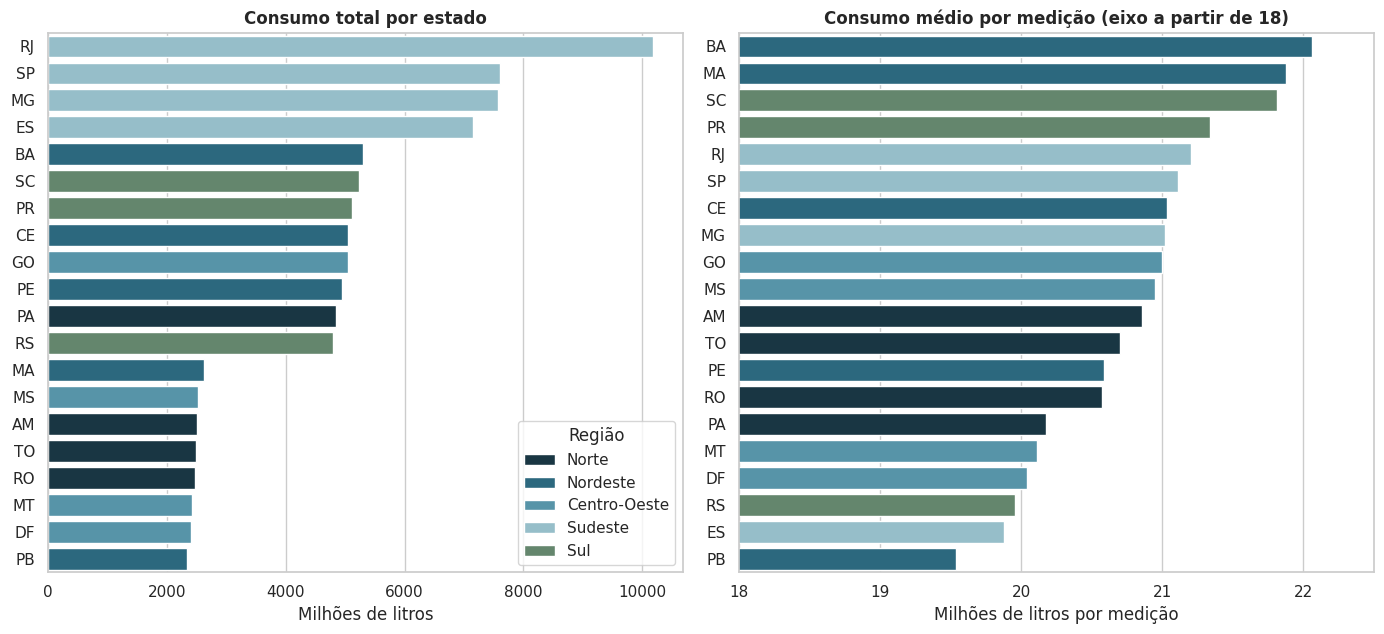

,uf,regiao,consumo_total,consumo_medio,medicoes
14,RJ,Sudeste,"10,175.87",21.20,480
18,SP,Sudeste,"7,600.36",21.11,360
7,MG,Sudeste,"7,566.11",21.02,360
4,ES,Sudeste,"7,155.60",19.88,360
1,BA,Nordeste,"5,294.28",22.06,240
17,SC,Sul,"5,235.36",21.81,240
13,PR,Sul,"5,121.17",21.34,240
2,CE,Nordeste,"5,048.74",21.04,240
5,GO,Centro-Oeste,"5,039.94",21.00,240
12,PE,Nordeste,"4,940.11",20.58,240


In [19]:
ranking_uf = (
    df.groupby(["uf", "regiao"])
    .agg(consumo_total=("consumo_milhoes_litros", "sum"),
         consumo_medio=("consumo_milhoes_litros", "mean"),
         medicoes=("consumo_milhoes_litros", "size"))
    .reset_index()
    .sort_values("consumo_total", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
ORDEM_REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
sns.barplot(data=ranking_uf, y="uf", x="consumo_total", hue="regiao", hue_order=ORDEM_REGIOES, dodge=False,
            palette=PALETA_SETORES, ax=axes[0])
axes[0].set_title("Consumo total por estado")
axes[0].set_xlabel("Milhões de litros")
axes[0].set_ylabel("")
axes[0].legend(title="Região", loc="lower right")

ranking_media = ranking_uf.sort_values("consumo_medio", ascending=False)
sns.barplot(data=ranking_media, y="uf", x="consumo_medio", hue="regiao", hue_order=ORDEM_REGIOES, dodge=False,
            palette=PALETA_SETORES, ax=axes[1], legend=False)
axes[1].set_title("Consumo médio por medição (eixo a partir de 18)")
axes[1].set_xlabel("Milhões de litros por medição")
axes[1].set_ylabel("")
axes[1].set_xlim(18, ranking_media["consumo_medio"].max() * 1.02)
plt.tight_layout()
salvar(fig, "ranking_estados")
plt.show()

ranking_uf.head(10)

**Interpretação:** no total, o ranking é liderado por **RJ, SP, MG e ES**, justamente os estados com mais medições por mês. Na média por medição, o ranking muda: **BA, MA e SC** lideram, e o RJ cai para a quinta posição. A resposta honesta à pergunta "quais estados consomem mais" depende do critério:

- Em volume acumulado registrado: RJ, SP e MG.
- Em intensidade por medição: BA, MA e SC, com diferenças pequenas (todos os estados ficam entre 19,5 e 22,1).

## 11.5 Comparação entre setores

In [20]:
resumo_setor = (
    df.groupby("setor_consumo")
    .agg(consumo_total=("consumo_milhoes_litros", "sum"),
         consumo_medio=("consumo_milhoes_litros", "mean"),
         medicoes=("consumo_milhoes_litros", "size"),
         desperdicio_medio=("desperdicio_percentual", "mean"),
         volume_perdido=("volume_perdido", "sum"))
    .sort_values("consumo_total", ascending=False)
)
resumo_setor["participacao_%"] = resumo_setor["consumo_total"] / resumo_setor["consumo_total"].sum() * 100
resumo_setor

,consumo_total,consumo_medio,medicoes,desperdicio_medio,volume_perdido,participacao_%
setor_consumo,,,,,,
Agrícola,"19,256.48",21.00,917,29.95,"5,804.82",20.80
Residencial,"19,211.75",21.07,912,30.52,"5,799.81",20.75
Comercial,"18,633.58",20.59,905,30.18,"5,594.41",20.13
Industrial,"18,046.49",20.79,868,30.24,"5,416.30",19.50
Público,"17,417.91",20.79,838,30.06,"5,255.17",18.82


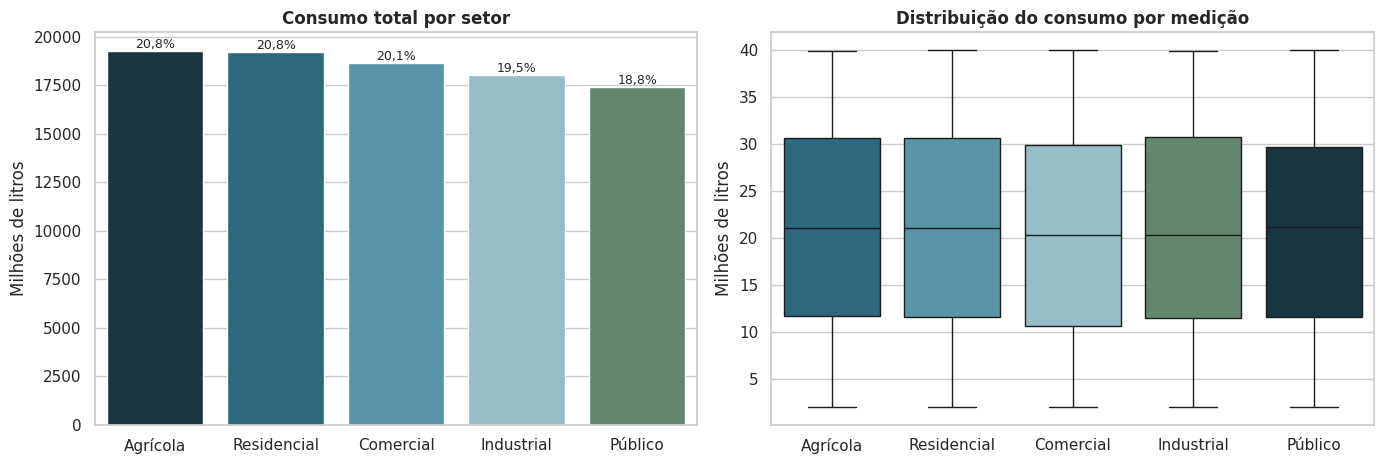

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(x=resumo_setor.index, y=resumo_setor["consumo_total"], palette=PALETA_SETORES,
            hue=resumo_setor.index, legend=False, ax=axes[0])
axes[0].set_title("Consumo total por setor")
axes[0].set_xlabel("")
axes[0].set_ylabel("Milhões de litros")
for i, (v, p) in enumerate(zip(resumo_setor["consumo_total"], resumo_setor["participacao_%"])):
    axes[0].text(i, v, f"{br(p, 1)}%", ha="center", va="bottom", fontsize=9)

sns.boxplot(data=df, x="setor_consumo", y="consumo_milhoes_litros", order=resumo_setor.index,
            palette=PALETA_SETORES, hue="setor_consumo", legend=False, ax=axes[1])
axes[1].set_title("Distribuição do consumo por medição")
axes[1].set_xlabel("")
axes[1].set_ylabel("Milhões de litros")
plt.tight_layout()
salvar(fig, "setores")
plt.show()

**Interpretação:** o setor **Agrícola** lidera o consumo total, praticamente empatado com o **Residencial** (cerca de 20,8% cada). O Público é o que menos consome. Os boxplots mostram distribuições muito parecidas entre setores, com medianas próximas de 21 milhões de litros. A diferença no total vem mais do número de medições de cada setor do que de um consumo mais intenso. Em bases reais, a agricultura costuma ser destacadamente a maior consumidora; aqui os setores estão equilibrados.

## 11.6 Relação entre chuva, estiagem e consumo

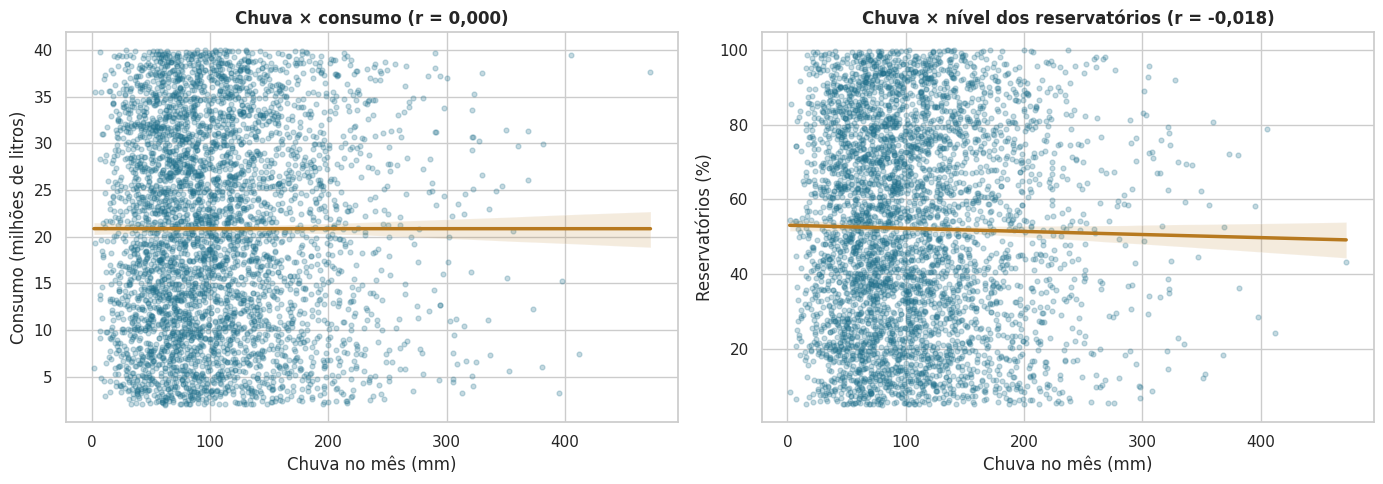

In [22]:
r_chuva_consumo = round(df["chuva_mm"].corr(df["consumo_milhoes_litros"]), 3) + 0.0
r_chuva_reserv = round(df["chuva_mm"].corr(df["reservatorios_percentual"]), 3) + 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=df, x="chuva_mm", y="consumo_milhoes_litros", ax=axes[0],
            scatter_kws={"alpha": 0.25, "s": 12, "color": AZUL}, line_kws={"color": OCRE, "linewidth": 2.5})
axes[0].set_title(f"Chuva × consumo (r = {r_chuva_consumo:.3f})".replace(".", ","))
axes[0].set_xlabel("Chuva no mês (mm)")
axes[0].set_ylabel("Consumo (milhões de litros)")

sns.regplot(data=df, x="chuva_mm", y="reservatorios_percentual", ax=axes[1],
            scatter_kws={"alpha": 0.25, "s": 12, "color": AZUL}, line_kws={"color": OCRE, "linewidth": 2.5})
axes[1].set_title(f"Chuva × nível dos reservatórios (r = {r_chuva_reserv:.3f})".replace(".", ","))
axes[1].set_xlabel("Chuva no mês (mm)")
axes[1].set_ylabel("Reservatórios (%)")
plt.tight_layout()
salvar(fig, "chuva_consumo")
plt.show()

In [23]:
comparacao_estiagem = df.groupby("estiagem").agg(
    medicoes=("consumo_milhoes_litros", "size"),
    consumo_medio=("consumo_milhoes_litros", "mean"),
    per_capita_medio=("consumo_per_capita", "mean"),
    reservatorios_medio=("reservatorios_percentual", "mean"),
    desperdicio_medio=("desperdicio_percentual", "mean"),
)
comparacao_estiagem

,medicoes,consumo_medio,per_capita_medio,reservatorios_medio,desperdicio_medio
estiagem,,,,,
Chuva normal,3336,20.91,267.28,52.21,30.27
Estiagem,1104,20.67,264.21,52.04,29.97


**Interpretação:** o coeficiente de correlação de Pearson entre chuva e consumo é praticamente zero (r ≈ 0,000), e a linha de regressão é horizontal. Nos meses de estiagem (chuva abaixo de 62,2 mm), o consumo médio por medição é quase igual ao dos meses com chuva normal, e o nível dos reservatórios também não cai. Até a relação entre chuva e reservatórios, que fisicamente deveria ser positiva, é nula na base (r ≈ −0,02). **Na base simulada, não há relação entre estiagem e consumo.**

Em dados reais, seria esperado que a estiagem reduzisse os reservatórios e, em crises, levasse a medidas de restrição que diminuem o consumo. A ausência desse efeito é uma característica da simulação, não uma conclusão sobre o Brasil.

## 11.7 Análise do desperdício

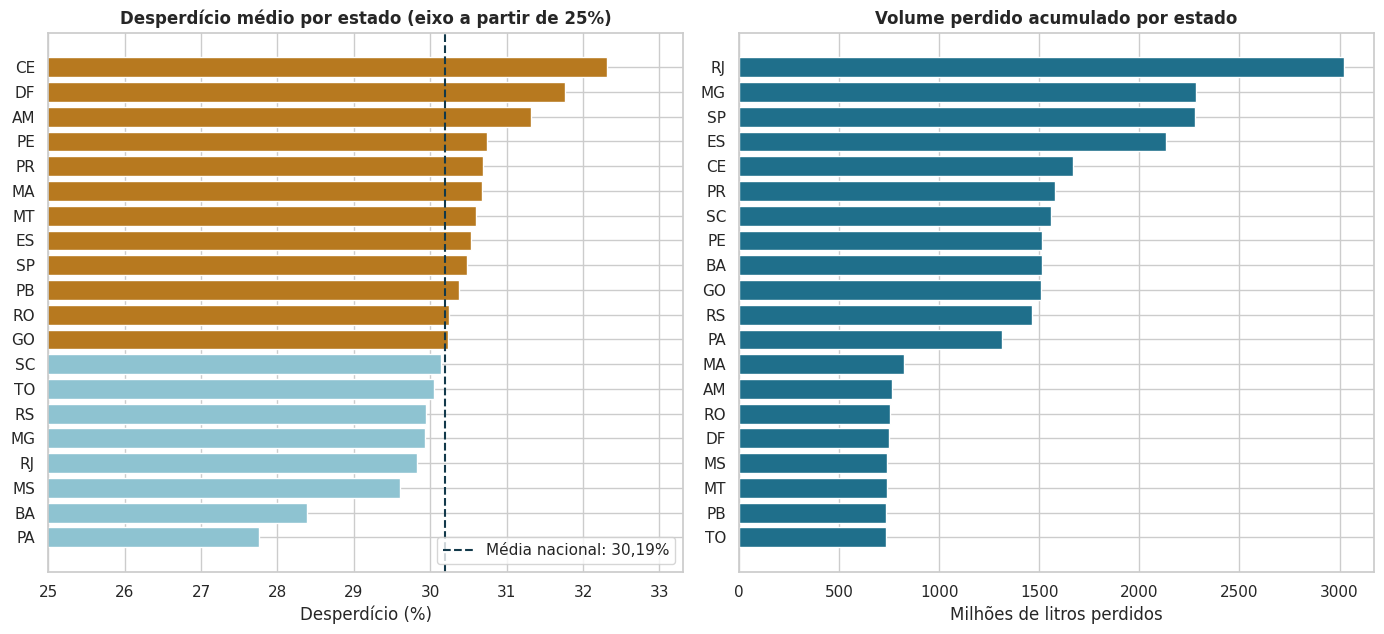

,desperdicio_medio,volume_perdido
uf,,
CE,32.31,"1,669.04"
DF,31.77,750.97
AM,31.32,763.65
PE,30.75,"1,515.44"
PR,30.69,"1,576.32"


In [24]:
desperdicio_uf = (
    df.groupby("uf")
    .agg(desperdicio_medio=("desperdicio_percentual", "mean"),
         volume_perdido=("volume_perdido", "sum"))
    .sort_values("desperdicio_medio", ascending=False)
)
media_nacional = df["desperdicio_percentual"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
cores = [OCRE if v > media_nacional else AZUL_CLARO for v in desperdicio_uf["desperdicio_medio"]]
axes[0].barh(desperdicio_uf.index[::-1], desperdicio_uf["desperdicio_medio"][::-1], color=cores[::-1])
axes[0].axvline(media_nacional, color=AZUL_ESCURO, linestyle="--", linewidth=1.5,
                label=f"Média nacional: {br(media_nacional)}%")
axes[0].set_xlim(25, desperdicio_uf["desperdicio_medio"].max() + 1)
axes[0].set_title("Desperdício médio por estado (eixo a partir de 25%)")
axes[0].set_xlabel("Desperdício (%)")
axes[0].legend(loc="lower right")

perdido_ordenado = desperdicio_uf.sort_values("volume_perdido")
axes[1].barh(perdido_ordenado.index, perdido_ordenado["volume_perdido"], color=AZUL)
axes[1].set_title("Volume perdido acumulado por estado")
axes[1].set_xlabel("Milhões de litros perdidos")
plt.tight_layout()
salvar(fig, "desperdicio")
plt.show()

desperdicio_uf.head(5)

In [25]:
desperdicio_ano = df.groupby("ano")["desperdicio_percentual"].mean()
print("Desperdício médio por ano:")
print(desperdicio_ano.round(2).to_string())
print(f"\nVariação 2015 → 2024: {br(desperdicio_ano.iloc[-1] - desperdicio_ano.iloc[0])} pontos percentuais")

Desperdício médio por ano:
ano
2015   28.72
2016   29.80
2017   30.50
2018   30.59
2019   29.63
2020   30.58
2021   30.22
2022   31.18
2023   30.68
2024   30.03

Variação 2015 → 2024: 1,32 pontos percentuais


**Interpretação:** os estados com maior desperdício médio são **CE (32,3%), DF (31,8%) e AM (31,3%)**. Os menores são PA (27,8%) e BA (28,4%). Em volume perdido, o RJ lidera com folga porque tem mais medições, então o percentual é a métrica correta para comparar eficiência.

O ponto mais relevante é o nível geral: o desperdício fica em torno de **30% em todos os estados, setores e anos**, e subiu cerca de 1,3 ponto percentual entre 2015 e 2024. Isso indica um problema estrutural de perdas, não algo concentrado em poucos estados. Reduzir perdas é a alavanca de maior impacto: cada ponto percentual a menos equivale a cerca de 926 milhões de litros na base.

## 11.8 Nível dos reservatórios e níveis de alerta

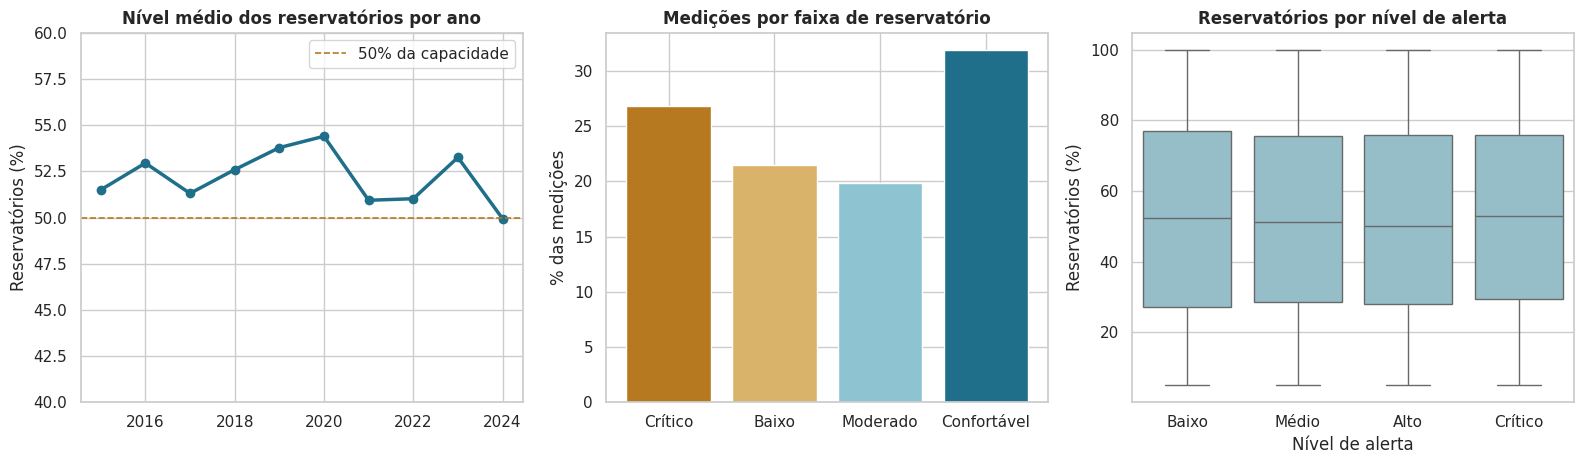

Faixas de reservatório (% das medições):
faixa_reservatorio
Crítico (≤30%)       26.80
Baixo (30–50%)       21.50
Moderado (50–70%)    19.90
Confortável (>70%)   31.80


In [26]:
reserv_anual = df.groupby("ano")["reservatorios_percentual"].mean()
reserv_regiao = df.groupby("regiao")["reservatorios_percentual"].mean().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].plot(reserv_anual.index, reserv_anual.values, marker="o", color=AZUL, linewidth=2.5)
axes[0].axhline(50, color=OCRE, linestyle="--", linewidth=1.2, label="50% da capacidade")
axes[0].set_title("Nível médio dos reservatórios por ano")
axes[0].set_ylabel("Reservatórios (%)")
axes[0].set_ylim(40, 60)
axes[0].legend()

faixas = df["faixa_reservatorio"].value_counts(normalize=True).sort_index() * 100
axes[1].bar(range(len(faixas)), faixas.values, color=[OCRE, "#D9B36A", AZUL_CLARO, AZUL])
axes[1].set_xticks(range(len(faixas)))
axes[1].set_xticklabels([f.split(" (")[0] for f in faixas.index])
axes[1].set_title("Medições por faixa de reservatório")
axes[1].set_ylabel("% das medições")

sns.boxplot(data=df, x="nivel_alerta", y="reservatorios_percentual", color=AZUL_CLARO, ax=axes[2])
axes[2].set_title("Reservatórios por nível de alerta")
axes[2].set_xlabel("Nível de alerta")
axes[2].set_ylabel("Reservatórios (%)")
plt.tight_layout()
salvar(fig, "reservatorios")
plt.show()

print("Faixas de reservatório (% das medições):")
print(faixas.round(1).to_string())

**Interpretação:** o nível médio dos reservatórios oscila entre 50% e 54% ao longo dos anos, com o menor valor em 2024 (49,9%). Cerca de **27% das medições estão com reservatórios abaixo de 30%**, faixa considerada crítica. Os boxplots confirmam a inconsistência apontada na limpeza: a distribuição dos reservatórios é a mesma para os quatro níveis de alerta, então o nível de alerta da base não reflete a situação hídrica medida.

## 11.9 Correlação estatística

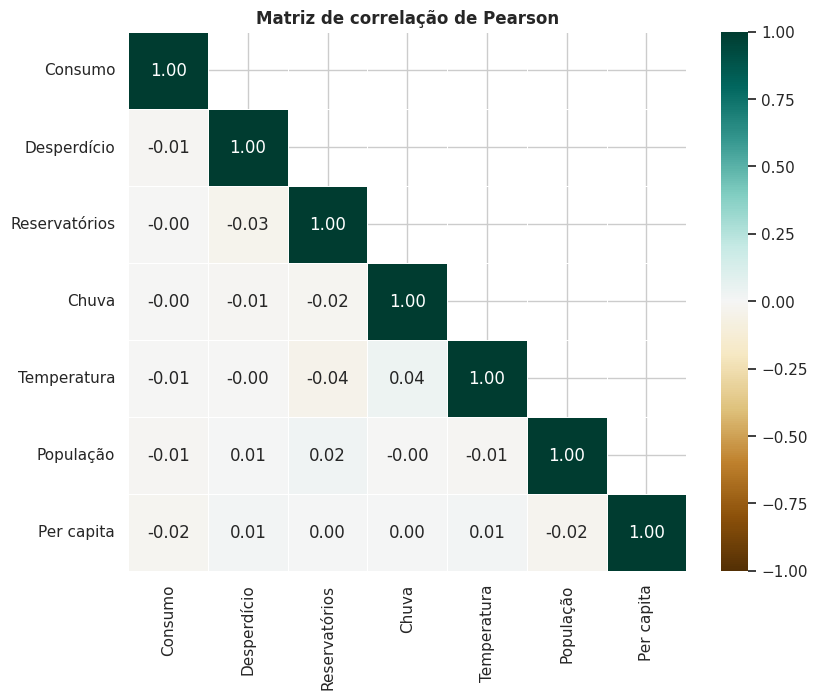

Maior correlação absoluta entre variáveis diferentes: 0.043


In [27]:
variaveis = ["consumo_milhoes_litros", "desperdicio_percentual", "reservatorios_percentual",
             "chuva_mm", "temperatura_media", "populacao", "consumo_per_capita"]
nomes = ["Consumo", "Desperdício", "Reservatórios", "Chuva", "Temperatura", "População", "Per capita"]
matriz_corr = df[variaveis].corr()
matriz_corr.index = nomes
matriz_corr.columns = nomes

fig, ax = plt.subplots(figsize=(9, 7))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt=".2f", cmap="BrBG", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlação de Pearson")
salvar(fig, "correlacao")
plt.show()

pares = matriz_corr.where(~mascara & ~np.eye(len(nomes), dtype=bool)).stack()
print(f"Maior correlação absoluta entre variáveis diferentes: {pares.abs().max():.3f}")

**Interpretação:** nenhuma correlação entre pares de variáveis ultrapassa 0,05 em valor absoluto. Pela escala usual, correlações abaixo de 0,1 são desprezíveis. As variáveis da base foram geradas de forma independente, então nenhum fator explica o consumo. Isso reforça as conclusões das seções anteriores: chuva, temperatura e população não influenciam o consumo nesta base.

## 11.10 Vulnerabilidade à escassez

Para responder se há regiões mais vulneráveis, foi construído um **índice de vulnerabilidade** de 0 a 100 por estado. Ele combina quatro fatores, cada um normalizado de 0 a 1 entre os estados (min-max), com peso igual:

- reservatórios mais baixos (invertido);
- chuva mais baixa (invertido);
- desperdício mais alto;
- maior proporção de medições em alerta Alto ou Crítico.

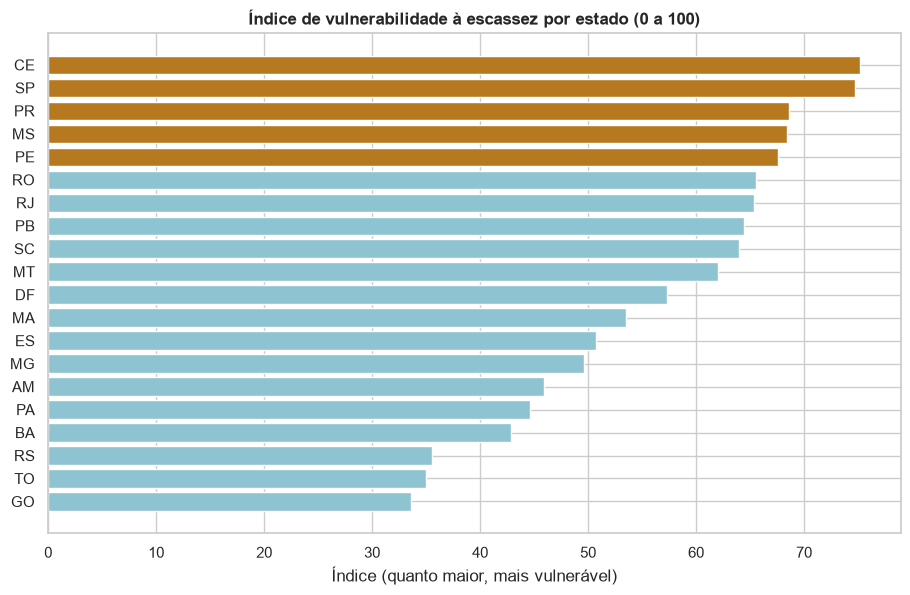

,uf,regiao,reservatorios,chuva,desperdicio,alerta_grave,indice_vulnerabilidade
2,CE,Nordeste,51.53,103.51,32.31,0.51,75.19
18,SP,Sudeste,49.55,106.13,30.48,0.53,74.67
13,PR,Sul,51.73,106.15,30.69,0.54,68.57
8,MS,Centro-Oeste,50.28,96.95,29.60,0.48,68.38
12,PE,Nordeste,50.75,109.76,30.75,0.53,67.62


In [16]:
fatores = df.groupby(["uf", "regiao"]).agg(
    reservatorios=("reservatorios_percentual", "mean"),
    chuva=("chuva_mm", "mean"),
    desperdicio=("desperdicio_percentual", "mean"),
    alerta_grave=("alerta_grave", "mean"),
).reset_index()

def normalizar(serie):
    return (serie - serie.min()) / (serie.max() - serie.min())

fatores["indice_vulnerabilidade"] = (
    (1 - normalizar(fatores["reservatorios"]))
    + (1 - normalizar(fatores["chuva"]))
    + normalizar(fatores["desperdicio"])
    + normalizar(fatores["alerta_grave"])
) / 4 * 100
fatores = fatores.sort_values("indice_vulnerabilidade", ascending=False)

fig, ax = plt.subplots(figsize=(11, 6.5))
cores = [OCRE if i < 5 else AZUL_CLARO for i in range(len(fatores))]
ax.barh(fatores["uf"][::-1], fatores["indice_vulnerabilidade"][::-1], color=cores[::-1])
ax.set_title("Índice de vulnerabilidade à escassez por estado (0 a 100)")
ax.set_xlabel("Índice (quanto maior, mais vulnerável)")
salvar(fig, "vulnerabilidade")
plt.show()

fatores.head(5)

In [17]:
fatores.groupby("regiao")["indice_vulnerabilidade"].mean().sort_values(ascending=False).to_frame()

,indice_vulnerabilidade
regiao,
Nordeste,60.72
Sudeste,60.10
Sul,56.03
Centro-Oeste,55.33
Norte,47.77


**Interpretação:** os estados mais vulneráveis pelo índice são **CE, SP, PR, MS e PE**. Cada um combina fatores diferentes: o CE tem o maior desperdício do país, SP tem um dos menores níveis médios de reservatório (49,5%), o MS tem a menor chuva média e PR e PE têm alta proporção de medições em alerta grave. Por região, Nordeste e Sudeste ficam no topo, e o Norte, com mais chuva, é a região menos vulnerável.

Como as diferenças entre estados nos fatores originais são pequenas, o índice serve como **priorização relativa**, não como sinal de risco absoluto.

# 12. Persistência em banco de dados (SQLAlchemy + SQLite)

In [30]:
NOMES_UF = {
    "AM": "Amazonas", "PA": "Pará", "RO": "Rondônia", "TO": "Tocantins",
    "BA": "Bahia", "PE": "Pernambuco", "CE": "Ceará", "MA": "Maranhão", "PB": "Paraíba",
    "DF": "Distrito Federal", "GO": "Goiás", "MT": "Mato Grosso", "MS": "Mato Grosso do Sul",
    "SP": "São Paulo", "RJ": "Rio de Janeiro", "MG": "Minas Gerais", "ES": "Espírito Santo",
    "PR": "Paraná", "SC": "Santa Catarina", "RS": "Rio Grande do Sul",
}

class Base(DeclarativeBase):
    pass

class Estado(Base):
    __tablename__ = "estados"
    uf: Mapped[str] = mapped_column(String(2), primary_key=True)
    nome: Mapped[str] = mapped_column(String(40))
    regiao: Mapped[str] = mapped_column(String(20))

class Medicao(Base):
    __tablename__ = "medicoes"
    id: Mapped[int] = mapped_column(Integer, primary_key=True, autoincrement=True)
    data: Mapped[str] = mapped_column(String(10))
    ano: Mapped[int] = mapped_column(Integer)
    mes: Mapped[int] = mapped_column(Integer)
    uf: Mapped[str] = mapped_column(ForeignKey("estados.uf"))
    setor_consumo: Mapped[str] = mapped_column(String(20))
    consumo_milhoes_litros: Mapped[float] = mapped_column(Float)
    desperdicio_percentual: Mapped[float] = mapped_column(Float)
    reservatorios_percentual: Mapped[float] = mapped_column(Float)
    chuva_mm: Mapped[float] = mapped_column(Float)
    temperatura_media: Mapped[float] = mapped_column(Float)
    populacao: Mapped[int] = mapped_column(Integer)
    consumo_per_capita: Mapped[float] = mapped_column(Float)
    nivel_alerta: Mapped[str] = mapped_column(String(10))

CAMINHO_BANCO = PASTA_DATABASE / "consumo_agua.sqlite"
engine = create_engine(f"sqlite:///{CAMINHO_BANCO.as_posix()}")
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

estados = (
    df[["uf", "regiao"]].drop_duplicates()
    .assign(nome=lambda d: d["uf"].map(NOMES_UF))[["uf", "nome", "regiao"]]
)
medicoes = df[["data", "ano", "mes", "uf", "setor_consumo", "consumo_milhoes_litros", "desperdicio_percentual",
               "reservatorios_percentual", "chuva_mm", "temperatura_media", "populacao",
               "consumo_per_capita", "nivel_alerta"]].copy()
medicoes["data"] = medicoes["data"].dt.strftime("%Y-%m-%d")
medicoes["nivel_alerta"] = medicoes["nivel_alerta"].astype(str)

estados.to_sql("estados", engine, if_exists="append", index=False)
medicoes.to_sql("medicoes", engine, if_exists="append", index=False)

with engine.connect() as conexao:
    for tabela in ["estados", "medicoes"]:
        total = conexao.execute(text(f"SELECT COUNT(*) FROM {tabela}")).scalar()
        print(f"Tabela {tabela}: {total} linhas")

Tabela estados: 20 linhas
Tabela medicoes: 4440 linhas


### Consultas SQL

In [31]:
consulta_regiao = '''
SELECT e.regiao,
       ROUND(SUM(m.consumo_milhoes_litros), 2) AS consumo_total,
       ROUND(AVG(m.consumo_milhoes_litros), 2) AS consumo_medio,
       ROUND(AVG(m.desperdicio_percentual), 2) AS desperdicio_medio,
       ROUND(AVG(m.reservatorios_percentual), 2) AS reservatorios_medio
FROM medicoes m
JOIN estados e ON e.uf = m.uf
GROUP BY e.regiao
ORDER BY consumo_total DESC
'''
pd.read_sql(consulta_regiao, engine)

,regiao,consumo_total,consumo_medio,desperdicio_medio,reservatorios_medio
0,Sudeste,"32,497.94",20.83,30.16,52.10
1,Nordeste,"20,252.66",21.10,30.49,51.98
2,Sul,"15,145.77",21.04,30.26,51.71
3,Centro-Oeste,"12,371.52",20.62,30.49,52.91
4,Norte,"12,298.32",20.50,29.42,52.46


In [32]:
consulta_critico = '''
SELECT e.nome AS estado,
       COUNT(*) AS medicoes_reservatorio_critico,
       ROUND(AVG(m.reservatorios_percentual), 2) AS reservatorio_medio_nessas_medicoes
FROM medicoes m
JOIN estados e ON e.uf = m.uf
WHERE m.reservatorios_percentual <= 30
GROUP BY e.nome
ORDER BY medicoes_reservatorio_critico DESC
LIMIT 5
'''
pd.read_sql(consulta_critico, engine)

,estado,medicoes_reservatorio_critico,reservatorio_medio_nessas_medicoes
0,Rio de Janeiro,126,16.38
1,São Paulo,106,17.79
2,Espírito Santo,97,17.17
3,Minas Gerais,91,18.76
4,Pernambuco,76,17.46


# 13. Interpretação dos resultados

| Pergunta | Resposta com base nos dados |
|---|---|
| Quais estados apresentam maior consumo de água? | Em volume total, **RJ, SP e MG**. Mas esses estados têm mais medições por mês. Na média por medição, **BA, MA e SC** lideram, com diferenças pequenas entre todos os estados. |
| Existe sazonalidade no consumo? | **Não de forma relevante.** O padrão do heatmap muda de ano para ano, e a diferença entre o maior e o menor mês médio é de cerca de 9%. |
| Quais setores consomem mais água? | **Agrícola** e **Residencial**, praticamente empatados com cerca de 20,8% do total cada. O setor Público é o que menos consome. |
| Há regiões mais vulneráveis à escassez? | Pelo índice de vulnerabilidade, **Nordeste e Sudeste**, puxados por CE (maior desperdício) e SP (reservatórios baixos). O Norte, com mais chuva, é o menos vulnerável. |
| Existe relação entre estiagem e consumo? | **Não.** A correlação entre chuva e consumo é praticamente zero, e o consumo nos meses de estiagem é igual ao dos meses normais. |
| Houve aumento do consumo ao longo do tempo? | **Não.** O consumo ficou estável, com variação de +0,5% entre 2015 e 2024. |
| Quais estados apresentam maiores índices de desperdício? | **CE, DF e AM**, todos acima de 31%. O desperdício médio é de cerca de 30% em todo o país. |

# 14. Conclusão

A análise mostra que, nesta base, **o consumo de água é estável e homogêneo**: não cresce ao longo do tempo, não tem sazonalidade forte e não responde a chuva, temperatura ou estiagem. As diferenças de volume total entre estados e regiões vêm principalmente da quantidade de medições, e não de um consumo mais intenso.

O que se destaca é o **desperdício**. Perto de 30% de toda a água registrada é perdida, o equivalente a quase 28 bilhões de litros em dez anos, e esse nível aparece em todos os estados e setores, com leve alta no período. Junto com reservatórios operando em média pouco acima de 50% da capacidade e cerca de 27% das medições abaixo de 30%, o quadro aponta que **a principal alavanca de gestão é reduzir perdas**, e não restringir o consumo de um setor específico.

Recomendações para gestores:

1. Priorizar programas de redução de perdas nos estados com maior desperdício percentual (CE, DF, AM).
2. Monitorar de perto os estados que lideram o índice de vulnerabilidade (CE, SP, PR, MS e PE) e os de reservatório médio mais baixo (SC e SP).
3. Revisar o critério de `nivel_alerta`, que hoje não acompanha o nível dos reservatórios.
4. Equilibrar a coleta de dados entre estados, já que a diferença no número de medições distorce as comparações por soma.

**Limitação:** a base é simulada e suas variáveis são independentes entre si. As conclusões descrevem os dados fornecidos e não devem ser generalizadas para a realidade hídrica do Brasil.